# Exploratory Data Analysis for QKD Eavesdropper Detection
This notebook performs the initial data exploration on the Quantum Key Distribution (QKD) dataset. We will analyze the features, check for anomalies, and prepare the dataset for the Autoencoder and XGBoost models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/raw/qkd_dataset_randomized.csv')
df.head()

,Sifted_Key_Length,QBER,Measurement_entropy,Signal_detection_rate,Decoy_detection_rate,Avg_Photon_time,Whole_key_time,Arrival_var,Arrival_dev,Label
0,296,0.016892,0.998386,0.521667,0.484497,0.068692,75.361209,0.000388,0.019708,pns_attack
1,311,0.016077,0.999635,0.522500,0.482560,0.072210,69.819607,0.000400,0.019998,pns_attack
2,262,0.259542,0.999327,0.462500,0.484983,0.071680,46.535641,0.000468,0.021636,mitm_attack
3,335,0.182090,0.999222,0.602500,0.552320,0.069888,40.625374,0.000447,0.021134,trojan_horse_attack
4,319,0.203762,0.999993,0.509167,0.487801,0.068840,66.490208,0.000383,0.019562,wavelength_dependent_trojan_attack


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sifted_Key_Length      8000 non-null   int64  
 1   QBER                   8000 non-null   float64
 2   Measurement_entropy    8000 non-null   float64
 3   Signal_detection_rate  8000 non-null   float64
 4   Decoy_detection_rate   8000 non-null   float64
 5   Avg_Photon_time        8000 non-null   float64
 6   Whole_key_time         8000 non-null   float64
 7   Arrival_var            8000 non-null   float64
 8   Arrival_dev            8000 non-null   float64
 9   Label                  8000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 625.1 KB


In [4]:
df.describe()

,Sifted_Key_Length,QBER,Measurement_entropy,Signal_detection_rate,Decoy_detection_rate,Avg_Photon_time,Whole_key_time,Arrival_var,Arrival_dev
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,304.85925,0.133833,0.984161,0.508013,0.494943,0.069985,67.726916,0.000399,0.019959
std,61.26121,0.118825,0.036784,0.100141,0.099905,0.001157,18.638785,0.000033,0.000824
min,147.00000,0.000000,0.768377,0.261667,0.238751,0.065738,35.009456,0.000284,0.016856
25%,270.00000,0.019355,0.994633,0.452292,0.440010,0.069212,51.780056,0.000377,0.019405
50%,317.00000,0.104167,0.998463,0.526667,0.513912,0.069996,67.661296,0.000398,0.019956
75%,355.00000,0.244002,0.999685,0.595833,0.571801,0.070749,83.947590,0.000421,0.020514
max,415.00000,0.383399,1.000000,0.649167,0.668930,0.075092,99.987326,0.000539,0.023220


In [5]:
df.isnull().sum()

Sifted_Key_Length        0
QBER                     0
Measurement_entropy      0
Signal_detection_rate    0
Decoy_detection_rate     0
Avg_Photon_time          0
Whole_key_time           0
Arrival_var              0
Arrival_dev              0
Label                    0
dtype: int64

## 1. Target Variable Distribution
Let's look at the distribution of the `Label` column, which indicates whether the record is normal or under attack.

In [8]:
df["Label"].value_counts()

Label
pns_attack                            1000
mitm_attack                           1000
trojan_horse_attack                   1000
wavelength_dependent_trojan_attack    1000
combined_attack                       1000
rng_attack                            1000
detector_blinding_attack              1000
normal                                1000
Name: count, dtype: int64

## 2. Correlation Matrix
Understanding the linear relationships between features.

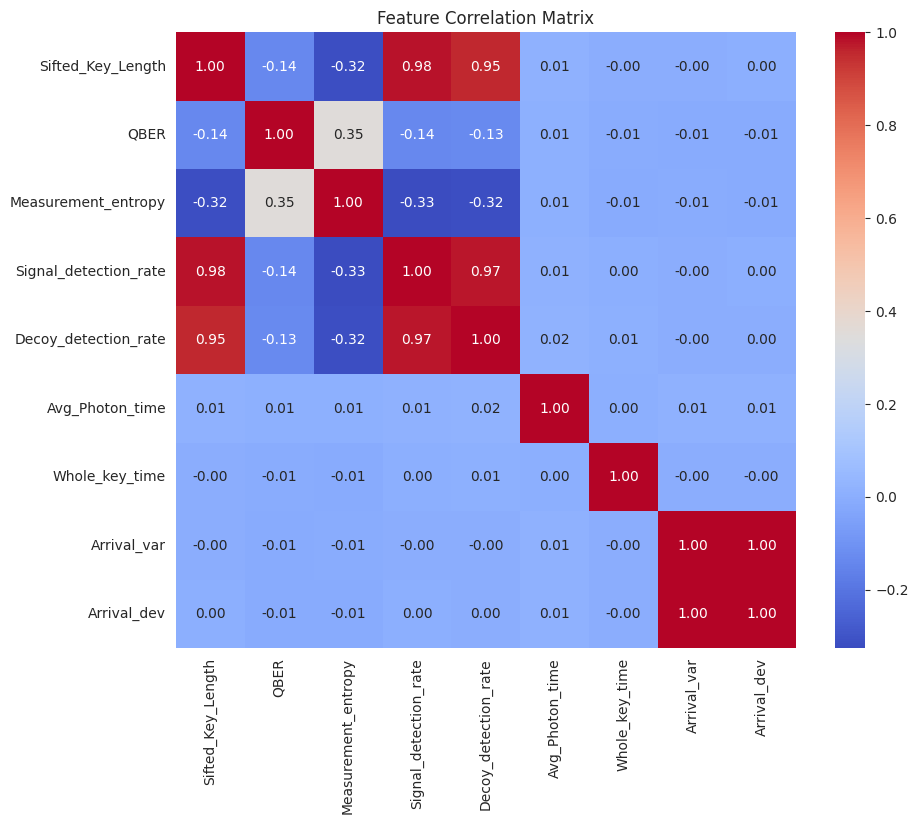

In [9]:
plt.figure(figsize=(10, 8))
corr = df.drop(columns=['Label']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 3. Feature Distributions by Attack Type
Visualizing how specific features differ between normal traffic and attacks.

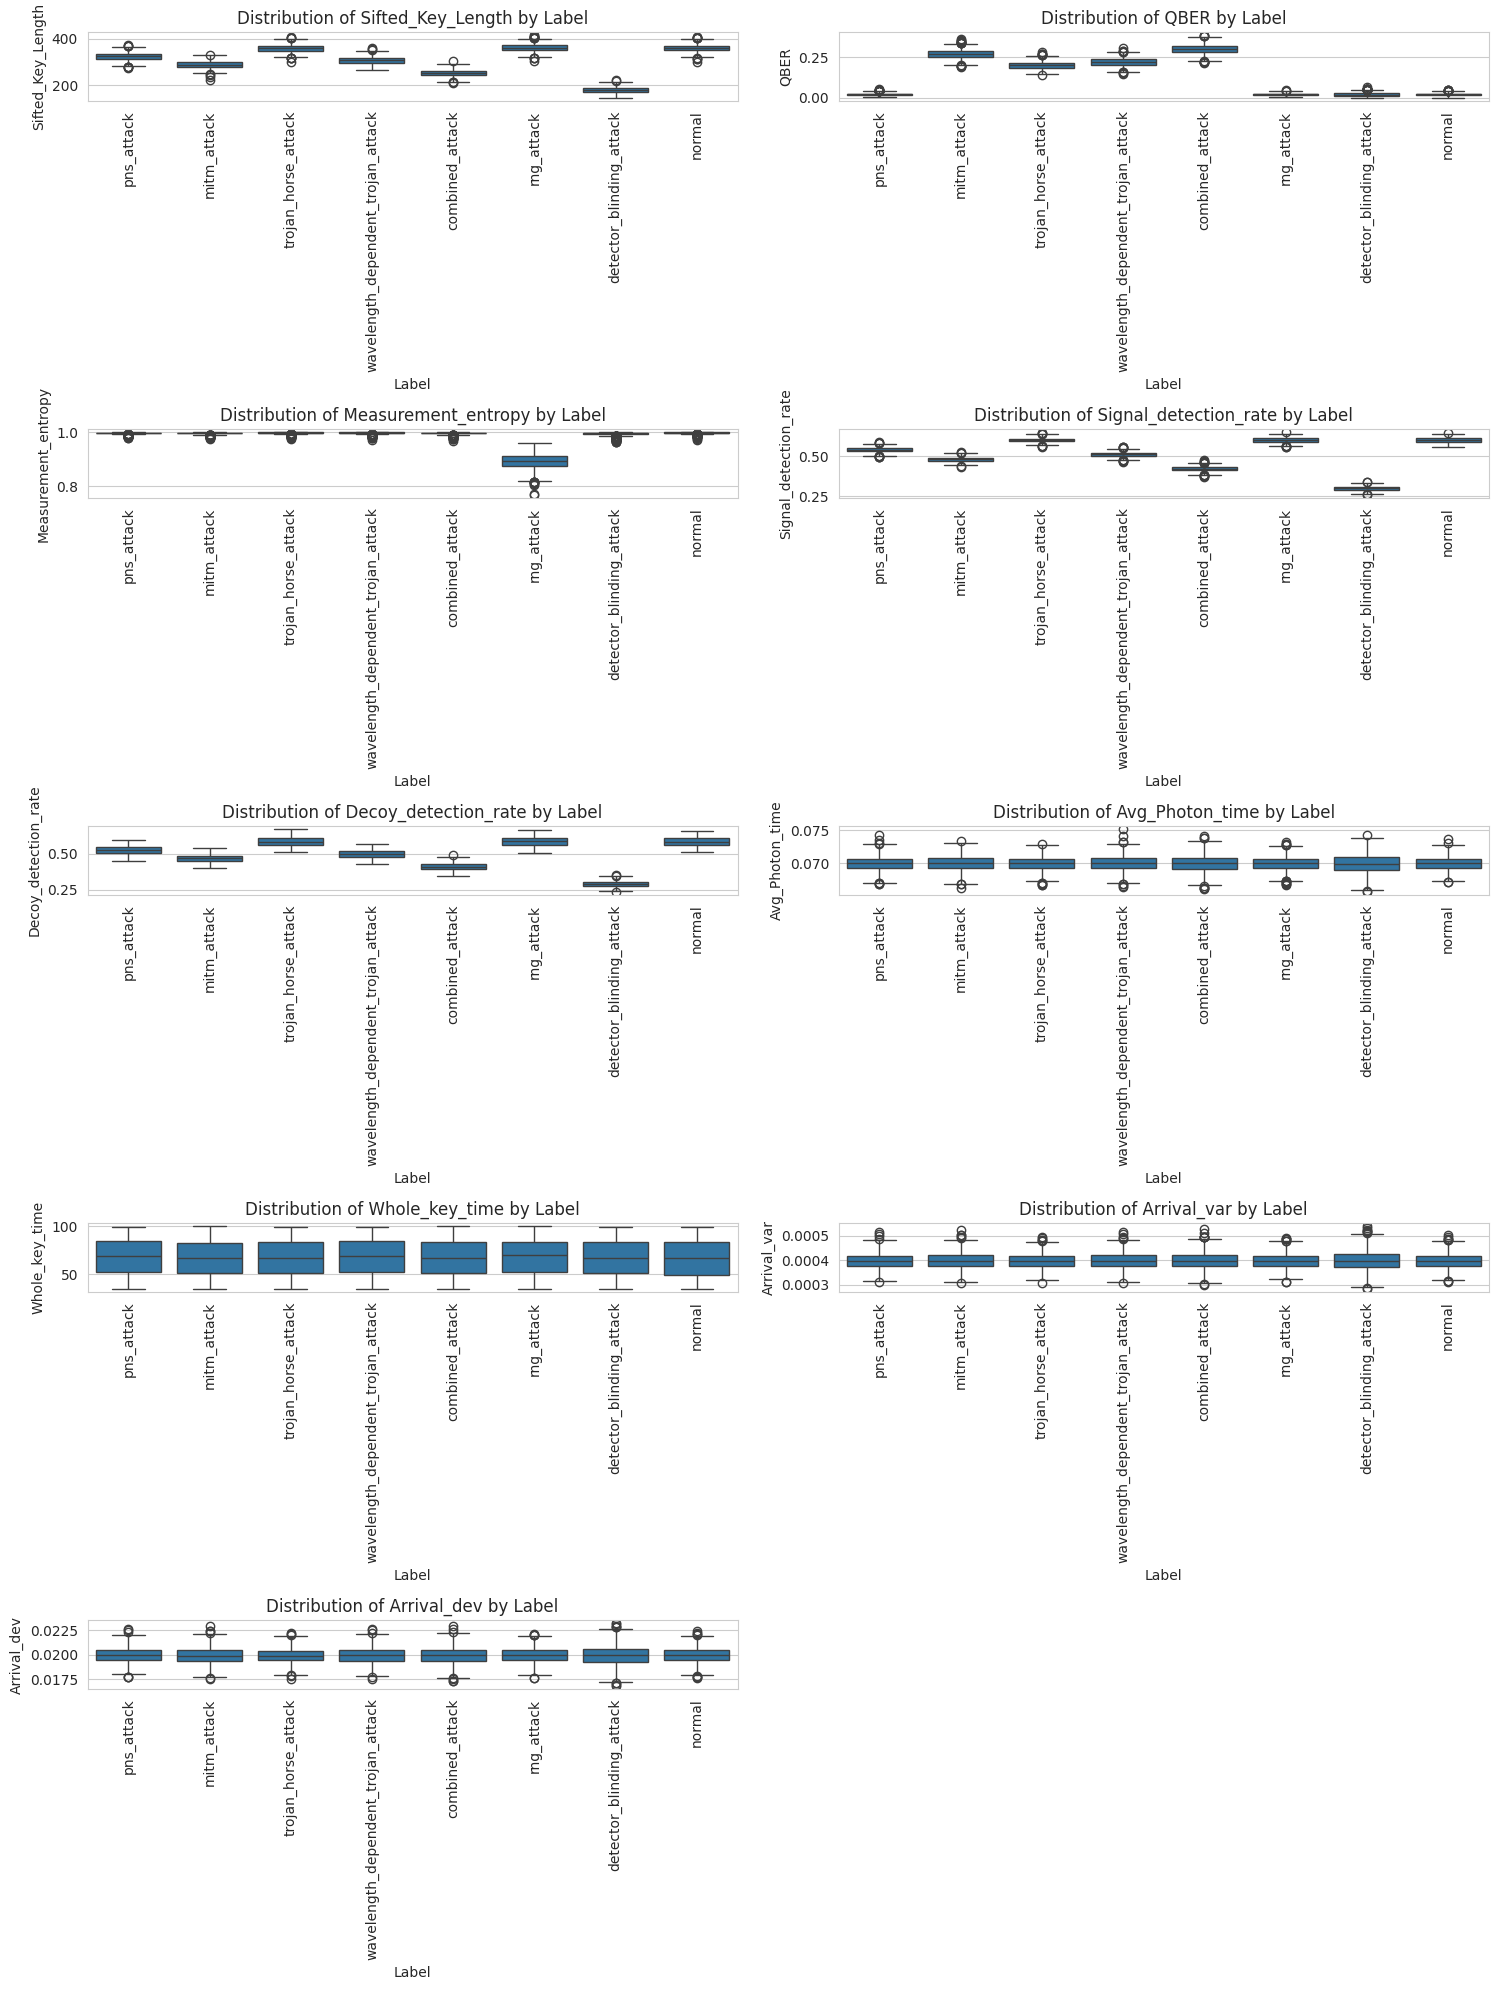

In [10]:
features = df.columns[:-1]
plt.figure(figsize=(15, 20))
for i, feature in enumerate(features):
    plt.subplot(5, 2, i+1)
    sns.boxplot(data=df, x='Label', y=feature)
    plt.xticks(rotation=90)
    plt.title(f'Distribution of {feature} by Label')
plt.tight_layout()
plt.show()

## Conclusion of EDA
Based on this EDA, we will next move to feature engineering, where we encode the categorical `Label` column, standardize the numerical features, and build our proposed Autoencoder + XGBoost models.